# Lab12 - PyTorch Training & AutoGrad

In [43]:
import torch
import torch.nn as nn
import numpy as np
import math
import matplotlib.pyplot as plt

torch.cuda.is_available()

True

## Ex. 0) Differentiation and Gradient Direction

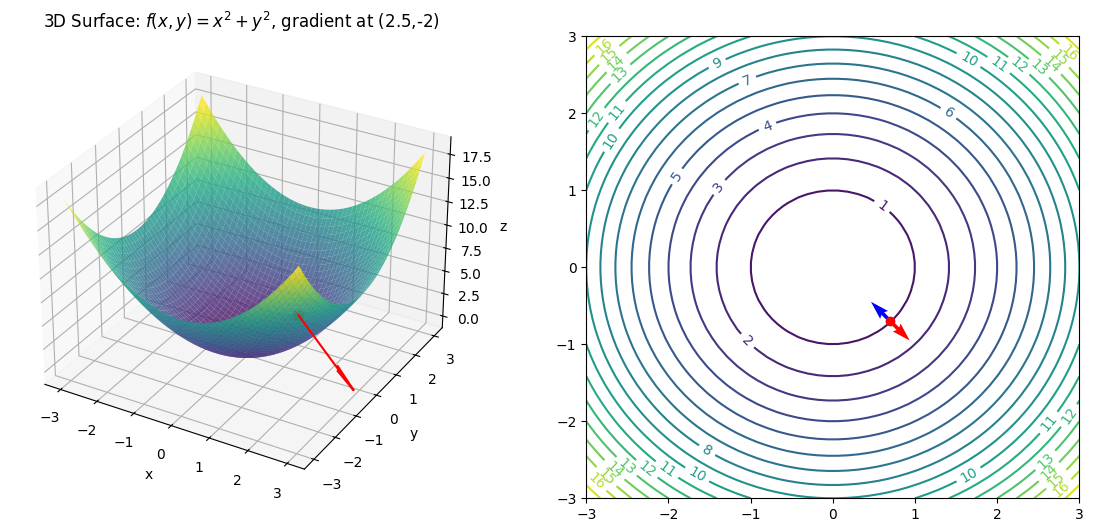

In [44]:
def f(x, y):  # Function is z = f(x,y) = x^2 + y^2
    return x**2 + y**2


def grad_f(x, y):  # Gradient is [2x, 2y]
    return np.array([2 * x, 2 * y])


# Grid for surface and contour
x = np.linspace(-3, 3, 50)
y = np.linspace(-3, 3, 50)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Consider a single point (x_0, y_0) = (2.5, -2.1)
x0, y0 = 2.5, -2.1
gx, gy = grad_f(x0, y0)
z0 = f(x0, y0)

# 1. 3D Surface Plot
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(X, Y, Z, cmap="viridis", alpha=0.8) # Function
ax1.scatter(x0, y0, z0, color="red", s=50) # Point
ax1.quiver(x0, y0, z0, gx, gy, 0, length=0.5, color="red") # Gradient Direction

ax1.set_title(r"3D Surface: $f(x,y)=x^2+y^2$, gradient at (2.5,-2)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

# 2. Contour + Gradient Vector
x0, y0 = 0.7, -0.7
gx, gy = grad_f(x0, y0)
z0 = f(x0, y0)

ax2 = fig.add_subplot(122)
contours = ax2.contour(X, Y, Z, levels=20, cmap="viridis")
ax2.clabel(contours) # Countourns
ax2.plot(x0, y0, "ro", markersize=6) # Point
ax2.quiver(x0, y0, gx, gy, color="red") # Gradient Direction
ax2.quiver(x0, y0, -gx, -gy, color="blue") # Inverse Gradient Direction

In [45]:
# First Example with Autograd

x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

z = x**2 + y**2
print("z =", z)

z.backward()
print("dz/dx =", x.grad) # dz/dx = 2*x
print("dz/dy =", y.grad) # dz/dy = 2*y

z = tensor(13., grad_fn=<AddBackward0>)
dz/dx = tensor(4.)
dz/dy = tensor(6.)


In [46]:
# Another example with Autograd

a = torch.tensor(4.0, requires_grad=True)
b = torch.tensor(2.0, requires_grad=True)

f = (a * b) + (a ** 2)
f.backward()

print("df/da =", a.grad)  # b + 2a
print("df/db =", b.grad)  # a

df/da = tensor(10.)
df/db = tensor(4.)


## Ex. 1) Derivatives using `torch.autograd.grad`

Let's compute the derivative of $sin(x)$ at $x$ in $[0,2\pi]$ using PyTorch's automatic differentiation
([link](https://pytorch.org/docs/stable/autograd.html)).



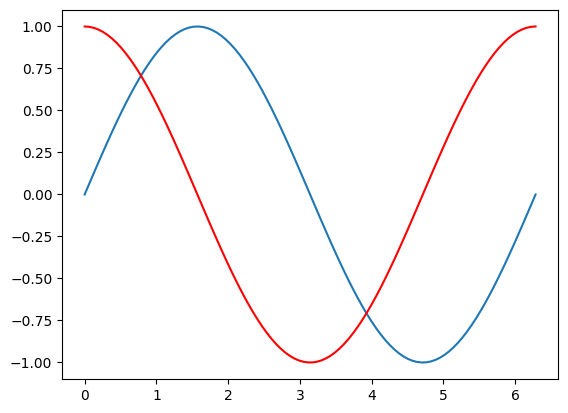

In [47]:
x = torch.linspace(0, 2*np.pi, 100, requires_grad=True)
y = torch.sin(x)

# y_prime = torch.autograd.grad(y.sum(), x)[0] # Derivative of sum of y with respect to x
y_prime = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y))[0] # Equivalent, more explicitly telling that

plt.plot(x.detach().numpy(), y.detach().numpy())
plt.plot(x.detach().numpy(), y_prime.detach().numpy(), color='red')
plt.show()

## Ex. 2) Complete Pytorch Training - Multi-Class Classification

This script demonstrates a complete neural network training workflow using PyTorch,
including:
- Data preparation
- Model definition
- Loss function and optimizer setup
- Complete training loop with autograd
- Evaluation and visualization

In [90]:
device = 'cuda' if torch.cuda.is_available else 'cpu'

device

'cuda'

In [ ]:
def create_synthetic_data(num_samples):
    """
    Creates a 2D synthetic dataset with 4 classes.
    Each class forms a cluster in 2D space.
    """
    # Cluster centers
    centers = torch.tensor([
        [2.0, 2.0],
        [-2.0, 2.0],
        [-2.0, -2.0],
        [2.0, -2.0]
    ], dtype=torch.float32)
    
    # Generate samples around each center
    X_list = []
    y_list = []
    samples_per_class = num_samples // 4
    
    for i in range(4):
        cluster = torch.randn(samples_per_class, 2) + centers[i]
        X_list.append(cluster)
        y_list.append(torch.full((samples_per_class,), i, dtype=torch.long))
    
    X = torch.cat(X_list, dim=0)
    y = torch.cat(y_list, dim=0)
    
    # Shuffle data
    perm = torch.randperm(num_samples)
    X = X[perm]
    y = y[perm]
    
    return X, y

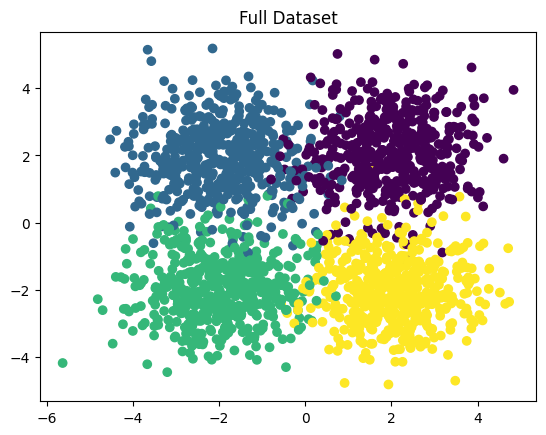

In [49]:
torch.manual_seed(42)
np.random.seed(42)

SAMPLES = 2000

X, y = create_synthetic_data(SAMPLES)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Full Dataset")
plt.show()

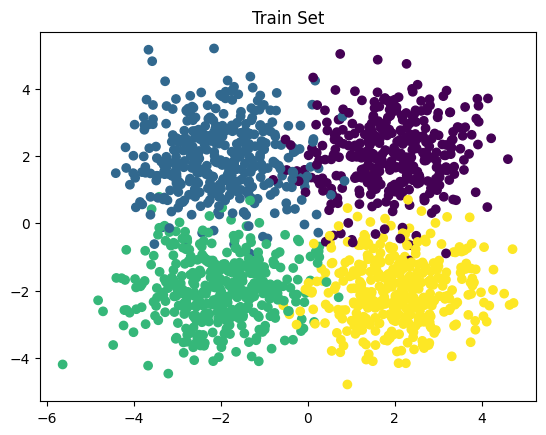

In [50]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.title("Train Set")
plt.show()

In [106]:
import torch.utils.data as data

class MyDataset(data.Dataset):
    
    def __init__(self, x, y):
        self.x = x
        self.y = y
        
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]
    
BATCH_SIZE = 128
LR = 1E-3
EPOCHS = 50

train_set = MyDataset(X_train, y_train)
test_set = MyDataset(X_test, y_test)

train_loader = data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
class Model(nn.Module):
    
    def __init__(self, n_input, n_hidden1, n_hidden2, n_output):
        super(Model, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_input, n_hidden1),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(n_hidden2, n_output)
        )
        
    def forward(self, x):
        return self.layers(x)
    
    
model = Model(2, 64, 32, 4)
model.to(device)

model

Model(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=32, out_features=4, bias=True)
  )
)

In [121]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_function = nn.CrossEntropyLoss()

losses = list()
train_accuracies = list()

for epoch in range(EPOCHS):
    current_loss = 0.0
    model.train()
    
    total, correct = 0, 0
    
    for i, batch in enumerate(train_loader):
        X_batch, y_batch_target = batch
        X_batch = X_batch.to(device)
        y_batch_target = y_batch_target.to(device)
        
        # Zero Gradients
        optimizer.zero_grad()
        
        # Forward Pass
        y_batch_logits = model(X_batch)
        
        # Compute Loss
        loss = loss_function(y_batch_logits, y_batch_target)
        current_loss += loss.item()
        y_batch_pred = torch.argmax(y_batch_logits, dim=1)
        total += len(y_batch_pred)
        correct += (y_batch_pred == y_batch_target).sum().item()
        
        # Backward Pass
        loss.backward()
        
        # Update Parameters
        optimizer.step()
        
    losses.append(current_loss)
    train_accuracies.append(correct / total)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:4d} | Train Loss {current_loss}")
    

print(f"Training has finished")



Epoch    0 | Train Loss 15.674102306365967
Epoch   10 | Train Loss 3.51657035946846
Epoch   20 | Train Loss 2.951898291707039
Epoch   30 | Train Loss 2.632370248436928
Epoch   40 | Train Loss 2.432934030890465
Training has finished


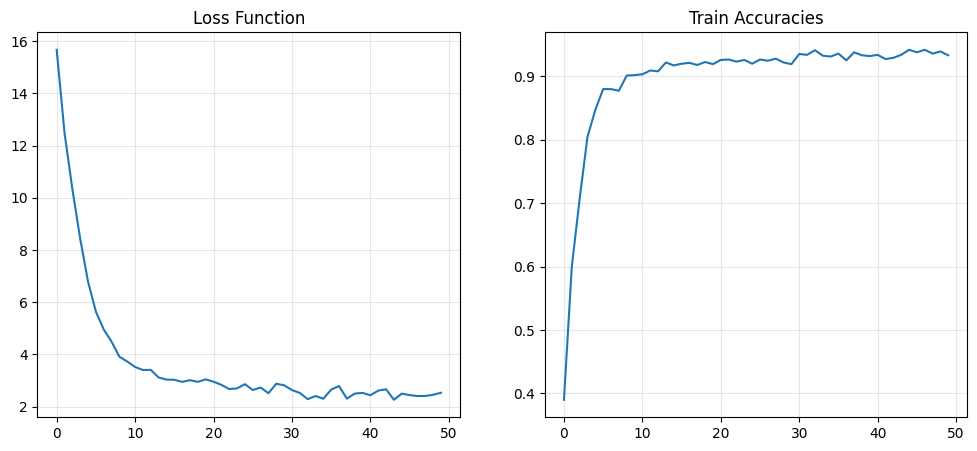

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1, ax2 = axes

ax1.plot(range(0, EPOCHS), losses)
ax1.set_title("Loss Function")
ax1.grid(True, alpha=0.3)

ax2.plot(range(0, EPOCHS), train_accuracies)
ax2.set_title("Train Accuracies")
ax2.grid(True, alpha=0.3)

plt.show()

In [124]:
from sklearn.metrics import confusion_matrix

model.to('cpu')
model.eval()
with torch.no_grad():
    y_test_logits = model(X_test)
    y_test_pred = torch.argmax(y_test_logits, dim=1)
    
confusion_matrix(y_test, y_test_pred)

array([[129,   2,   0,   3],
       [  2, 113,   5,   0],
       [  0,   3, 110,   4],
       [  2,   0,   1, 126]])

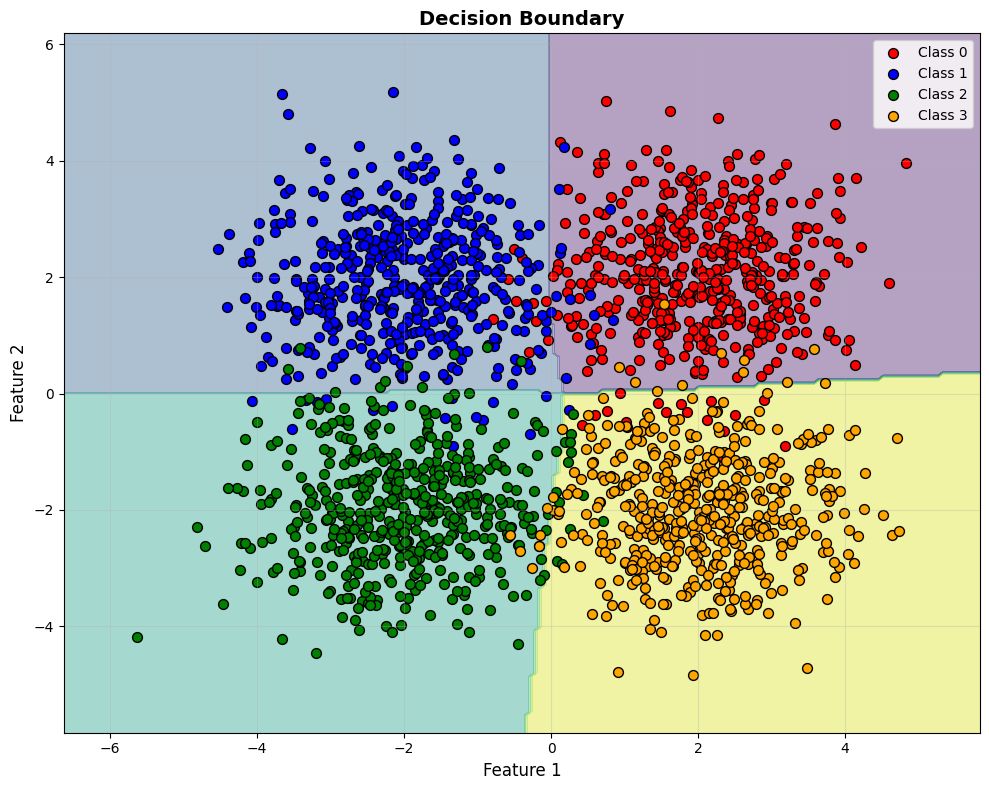

In [126]:
model.to('cpu')
model.eval()

# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                        np.linspace(y_min, y_max, 200))

# Convert to tensor and predict
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    Z = model(grid)
    _, Z = torch.max(Z, 1)

Z = Z.numpy().reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Contour plot
ax.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')

# Scatter plot of data points
colors = ['red', 'blue', 'green', 'orange']
for i in range(4):
    mask = y == i
    ax.scatter(X[mask, 0], X[mask, 1], c=colors[i], 
                label=f'Class {i}', edgecolors='k', s=50)

ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title("Decision Boundary", fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Ex. 3) Hand-built Regression Training

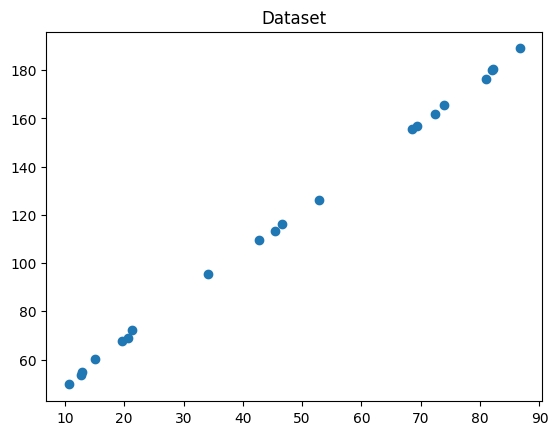

In [181]:
def F2C(x): # Fahrenheit to Celsius
    return (x - 32) * 5.0/9.0

def C2F(x): # Celsius to Fahrenheit
    return x * 9.0/5.0 + 32

def termometer(N, noise=5):
    c = torch.rand(N)*100   # Celsius from 30 to 42 
    f = C2F(c)
    return c, f + noise*torch.randn(N)

x, y = termometer(20, noise=1)

plt.scatter(x,y)
plt.title("Dataset")
plt.show()

In [182]:
def model(x, w, b):
    return w * x + b

def loss_function(real, pred):
    sse = (real - pred) ** 2
    return sse.mean()

w = torch.tensor(1.0)
b = torch.tensor(0.0)

x = 0.1 * x # Why? Training is not stable without it, it's like a normalization

In [183]:
EPOCHS = 5000
LR = 5E-3

for epoch in range(EPOCHS):
    
    # Forward Pass
    y_pred = model(x, w, b)
    
    # Loss Function
    loss = loss_function(y, y_pred)
    
    # Backward Pass (manually)
    N = y_pred.size(0)
    error = y_pred - y
    wgrad = (2/N) * (error * x).sum()
    bgrad = (2/N) * error.sum()
    
    # Parameters Optimization
    w -= LR * wgrad
    b -= LR * bgrad

    if epoch % 500 == 0:
        print(f'Epoch {epoch:4d} | loss {loss:5.5f} | Params w={w:3.3f} b={b:3.3f}')

Epoch    0 | loss 14855.30273 | Params w=7.603 b=1.129
Epoch  500 | loss 19.41998 | Params w=19.405 b=23.386
Epoch 1000 | loss 2.59790 | Params w=18.433 b=29.439
Epoch 1500 | loss 1.03362 | Params w=18.137 b=31.285
Epoch 2000 | loss 0.88816 | Params w=18.047 b=31.848
Epoch 2500 | loss 0.87464 | Params w=18.019 b=32.020
Epoch 3000 | loss 0.87338 | Params w=18.011 b=32.072
Epoch 3500 | loss 0.87326 | Params w=18.008 b=32.088
Epoch 4000 | loss 0.87325 | Params w=18.007 b=32.093
Epoch 4500 | loss 0.87325 | Params w=18.007 b=32.094


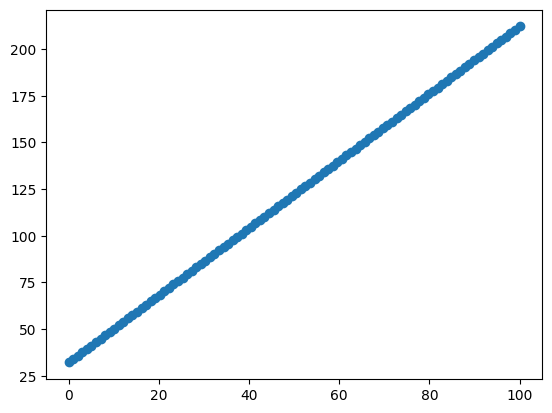

In [184]:
x = torch.linspace(0, 100, 100)
y = model(x*0.1, w, b)

plt.scatter(x, y)
plt.show()

In [ ]:
model(100*0.1, w, b) # Expected: 100 Celsius = 212 Fahrenheit 

tensor(212.1663)